<div align="center">
<h1>04 — Labeling dan Insight: UNU-KEYs, Caption, Risiko</h1>
<p>Berangkat dari 17 label terkunci menuju grounding taksonomi, audit caption, dan peta risiko.</p>
</div>

## ***Setup***
---
Menyiapkan import, seed, path audit, dan penanda model caption yang unverified.

Import pustaka ringan CPU dan memastikan folder audit caption tersedia sebelum analisis.

In [1]:
import random, json, re, hashlib
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from collections import Counter
from IPython.display import Image as NBImage, display as nbdisplay

random.seed(42); np.random.seed(42)
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 120})
plt.ioff()

ROOT = Path.cwd()
while not (ROOT / "AGENTS.md").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
PROC = ROOT / "data" / "processed" / "electronic"
KEC = PROC / "kec_drowcula_dinov3"
FIG = KEC / "figures"
AUD = KEC / "caption_audit_v1"
assert AUD.exists(), f"audit tidak ada: {AUD}"
print("ROOT:", ROOT)
print("caption model: UNVERIFIED (tidak tercatat di captions.csv)")
print("numpy", np.__version__, "| pandas", pd.__version__, "| matplotlib", matplotlib.__version__)


ROOT: /home/varys/orca/workspaces/2026_SatriaData_SemiFinal/DROWCULA-MODELLING
caption model: UNVERIFIED (tidak tercatat di captions.csv)
numpy 2.3.5 | pandas 3.0.3 | matplotlib 3.11.0


## ***Label Terkunci***
---
Memuat 17 label final manusia sebagai satu-satunya acuan penamaan klaster.

Menampilkan pemetaan klaster ke kode UNU-KEY, kategori EU/GAP, dan status vote otomatis.

In [2]:
final = pd.read_csv(KEC / "final_cluster_labels.csv")
sizes = pd.read_csv(KEC / "cluster_sizes.csv")
t = sizes.merge(final, on="cluster").sort_values("cluster")
t[["cluster", "n_samples", "final_label", "unu_key_code", "eu_category", "vote_code", "vote_agreement"]]


,cluster,n_samples,final_label,unu_key_code,eu_category,vote_code,vote_agreement
0,0,281,Printers and scanners,0304,Small IT,0304,agree
1,1,524,Mobile Phones and smartphones,0306,Small IT,0306,agree
2,2,357,Mixed e-waste scrap pile,GAP-SCRAP,Basel Y49 / HS 8549.99,GAP-SCRAP,agree
3,3,290,Keyboards and input devices,0301,Small IT,0301,agree
4,4,101,Washing Machines (top-load),0104,Large equipment (excl. PV),0102,human correction
5,5,343,Computer mice and pointing devices,0301,Small IT,0301,agree
6,6,141,Televisions (flat-panel),0408,Screens and monitors,0405,human correction
7,7,242,Microwaves,0114,Small equipment,0202,human correction
8,8,228,Laptops and tablets,0303,Screens and monitors,0301/0405/0407?,human correction
9,9,277,Portable batteries,GAP-BATT,Basel A1181 / HS 8549.21,GAP-BATT,agree


Menghitung berapa klaster yang disepakati vote otomatis dan berapa yang dikoreksi manusia.

In [3]:
s = final["vote_agreement"].value_counts()
pd.DataFrame([{"sepakat": int(s.get("agree", 0)), "koreksi_manusia": int(s.get("human correction", 0)),
               "klaster_dikoreksi": final[final.vote_agreement == "human correction"]["cluster"].tolist()}])


,sepakat,koreksi_manusia,klaster_dikoreksi
0,7,10,"[4, 6, 7, 8, 10, 11, 13, 14, 15, 16]"


## ***Grounding SigLIP2***
---
Metode dua lapis: cosine centroid menjawab kemiripan rata-rata klaster, vote per citra menjawab distribusi anggotanya. Keduanya memakai SigLIP2 base-patch16-256 dengan 3 template e-waste dan 57 UNU-KEY plus 3 kategori GAP. Ambang HIGH 0.04, aturan GAP menang bila melampaui UNU terbaik lebih dari 0.005.

Menampilkan cosine, margin, kepercayaan, dan hasil vote tiap klaster dalam satu tabel.

In [4]:
g = pd.read_csv(KEC / "cluster_grounding.csv")
show = g[["cluster", "n_samples", "unu_key_code", "primary_category", "cosine_score",
          "margin_vs_second", "confidence", "vote_code", "vote_winner_share", "vote_confidence"]].copy()
for c in ["cosine_score", "margin_vs_second", "vote_winner_share"]:
    show[c] = show[c].round(4)
show


,cluster,n_samples,unu_key_code,primary_category,cosine_score,margin_vs_second,confidence,vote_code,vote_winner_share,vote_confidence
0,0,281,0304,"Printers and scanners, copiers",0.1350,0.0249,MODERATE,0304,0.8399,MAJORITY
1,1,524,0306,Mobile Phones and smartphones,0.1119,0.0064,LOW,0306,0.6527,MAJORITY
2,2,357,0802,Professional Medical equipment,0.1358,0.0004,LOW,GAP-SCRAP,0.2801,HETEROGENEOUS (COVERAGE_GAP)
3,3,290,0301,"Small IT equipment, routers, mice and keyboards",0.1195,0.0310,MODERATE,0301,0.9172,MAJORITY
4,4,101,0102,Dishwashers,0.1158,0.0362,MODERATE,0102,0.8614,MAJORITY
5,5,343,0301,"Small IT equipment, routers, mice and keyboards",0.1286,0.0309,MODERATE,0301,0.9446,MAJORITY
6,6,141,0405,Speakers,0.0854,0.0031,LOW,0405/0111/0404?,0.4468,PLURALITY
7,7,242,0202,"Equipment for food preparation, toasters and g...",0.1114,0.0224,MODERATE,0202,0.8678,MAJORITY
8,8,228,0301,"Small IT equipment, routers, mice and keyboards",0.1048,0.0004,LOW,0301/0405/0407?,0.3289,HETEROGENEOUS
9,9,277,GAP-BATT,"Portable batteries, dry cells, accumulator cel...",0.1062,0.0035,HIGH (COVERAGE_GAP:BATT),GAP-BATT,0.7292,MAJORITY (COVERAGE_GAP)


Menggambar cosine dan margin tiap klaster dengan garis ambang HIGH untuk menunjukkan tidak ada yang lolos.

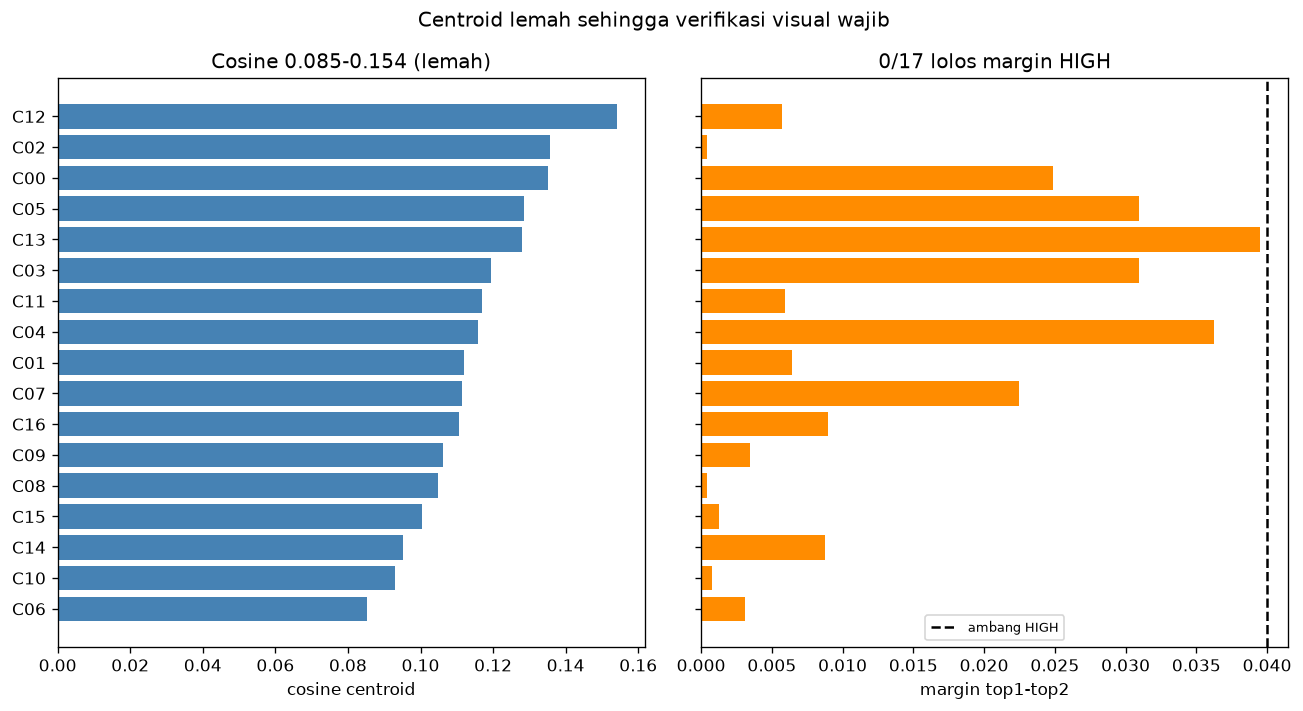

In [5]:
g = pd.read_csv(KEC / "cluster_grounding.csv").sort_values("cosine_score")
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 6), sharey=True)
a1.barh([f'C{r.cluster:02d}' for r in g.itertuples()], g["cosine_score"], color="steelblue")
a1.set_xlabel("cosine centroid"); a1.set_title("Cosine 0.085-0.154 (lemah)")
a2.barh([f'C{r.cluster:02d}' for r in g.itertuples()], g["margin_vs_second"], color="darkorange")
a2.axvline(0.04, ls="--", c="k", label="ambang HIGH")
a2.set_xlabel("margin top1-top2"); a2.legend(fontsize=8); a2.set_title("0/17 lolos margin HIGH")
fig.suptitle("Centroid lemah sehingga verifikasi visual wajib")
fig.tight_layout()
plt.show(fig)


Menggambar pangsa vote per citra dengan garis mayoritas dan pluralitas untuk memisahkan klaster murni dari campuran.

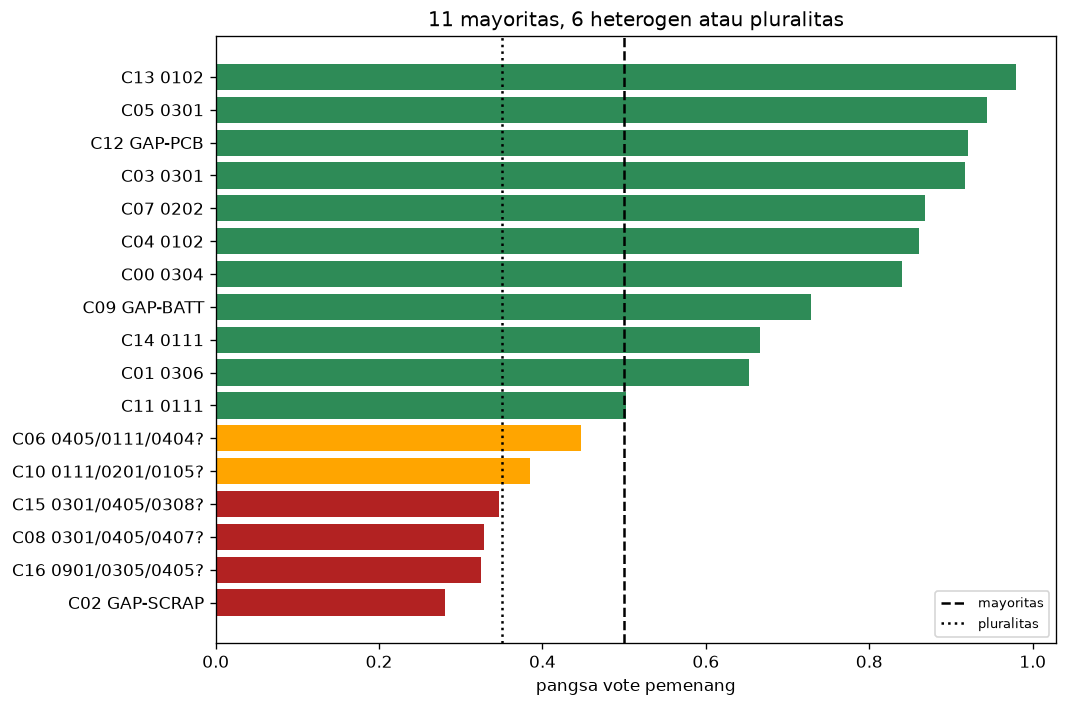

In [6]:
g = pd.read_csv(KEC / "cluster_grounding.csv").sort_values("vote_winner_share")

def vote_color(v):
    v = str(v)
    if "MAJORITY" in v:
        return "seagreen"
    if "PLURALITY" in v:
        return "orange"
    return "firebrick"

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh([f'C{r.cluster:02d} {str(r.vote_code)[:18]}' for r in g.itertuples()],
        g["vote_winner_share"], color=[vote_color(r.vote_confidence) for r in g.itertuples()])
ax.axvline(0.5, ls="--", c="k", label="mayoritas"); ax.axvline(0.35, ls=":", c="k", label="pluralitas")
ax.set_xlabel("pangsa vote pemenang"); ax.legend(fontsize=8)
ax.set_title("11 mayoritas, 6 heterogen atau pluralitas")
fig.tight_layout()
plt.show(fig)


Merinci 7 klaster bermasalah: tebakan centroid, 3 kandidat teratas, vote, dan label finalnya.

In [7]:
d = json.load(open(KEC / "cluster_grounding.json"))
rows = []
for c in [2, 6, 8, 10, 14, 15, 16]:
    x = d[f"cluster_{c:02d}"]
    top = x["top_matches"][:3]
    mv = x["majority_vote"]
    frow = final[final.cluster == c].iloc[0]
    rows.append({"klaster": f"C{c:02d}",
                 "centroid": f'{x["assigned_unu_key"]["code"]} ({top[0]["cosine"]:.3f})',
                 "top3": "; ".join(f'{t["code"]}:{t["cosine"]:.3f}' for t in top),
                 "vote": f'{mv["winner"]["code"]} {mv["winner"]["share"]:.0%} [{mv["vote_confidence"]}]',
                 "final": f'{frow["unu_key_code"]} {frow["final_label"][:30]}'})
pd.DataFrame(rows)


,klaster,centroid,top3,vote,final
0,C02,0802 (0.136),0802:0.136; 0113:0.135; 0703:0.134,GAP-SCRAP 28% [HETEROGENEOUS (COVERAGE_GAP)],GAP-SCRAP Mixed e-waste scrap pile
1,C06,0405 (0.085),0405:0.085; 0111:0.082; 0204:0.082,0405 45% [PLURALITY],0408 Televisions (flat-panel)
2,C08,0301 (0.105),0301:0.105; 0405:0.104; 0407:0.103,0301 33% [HETEROGENEOUS],0303 Laptops and tablets
3,C10,0111 (0.093),0111:0.093; 0113:0.092; 0802:0.092,0111 39% [PLURALITY],0403 Radio and Hi-Fi / music player
4,C14,0111 (0.095),0111:0.095; 0802:0.087; 0113:0.086,0111 67% [MAJORITY],0403 Radio and Hi-Fi equipment
5,C15,0405 (0.100),0405:0.100; 0301:0.099; 0204:0.098,0301 35% [HETEROGENEOUS],0309 Flat-Panel Display Monitors
6,C16,0901 (0.111),0901:0.111; 0405:0.102; 0201:0.099,0901 32% [HETEROGENEOUS],GAP-OTHER Power outlets and switches (no


### ***Kasus C02***
Kasus paling ekstrem: centroid menebak peralatan medis 0802 dengan margin 0.0004, sedangkan vote tercerai dengan SCRAP hanya 28%. Grid top-9 dan far-9 di bawah menjadi bukti visual bahwa isinya tumpukan campuran.

Menampilkan grid 9 citra terdekat centroid C02 sebagai bukti campuran.

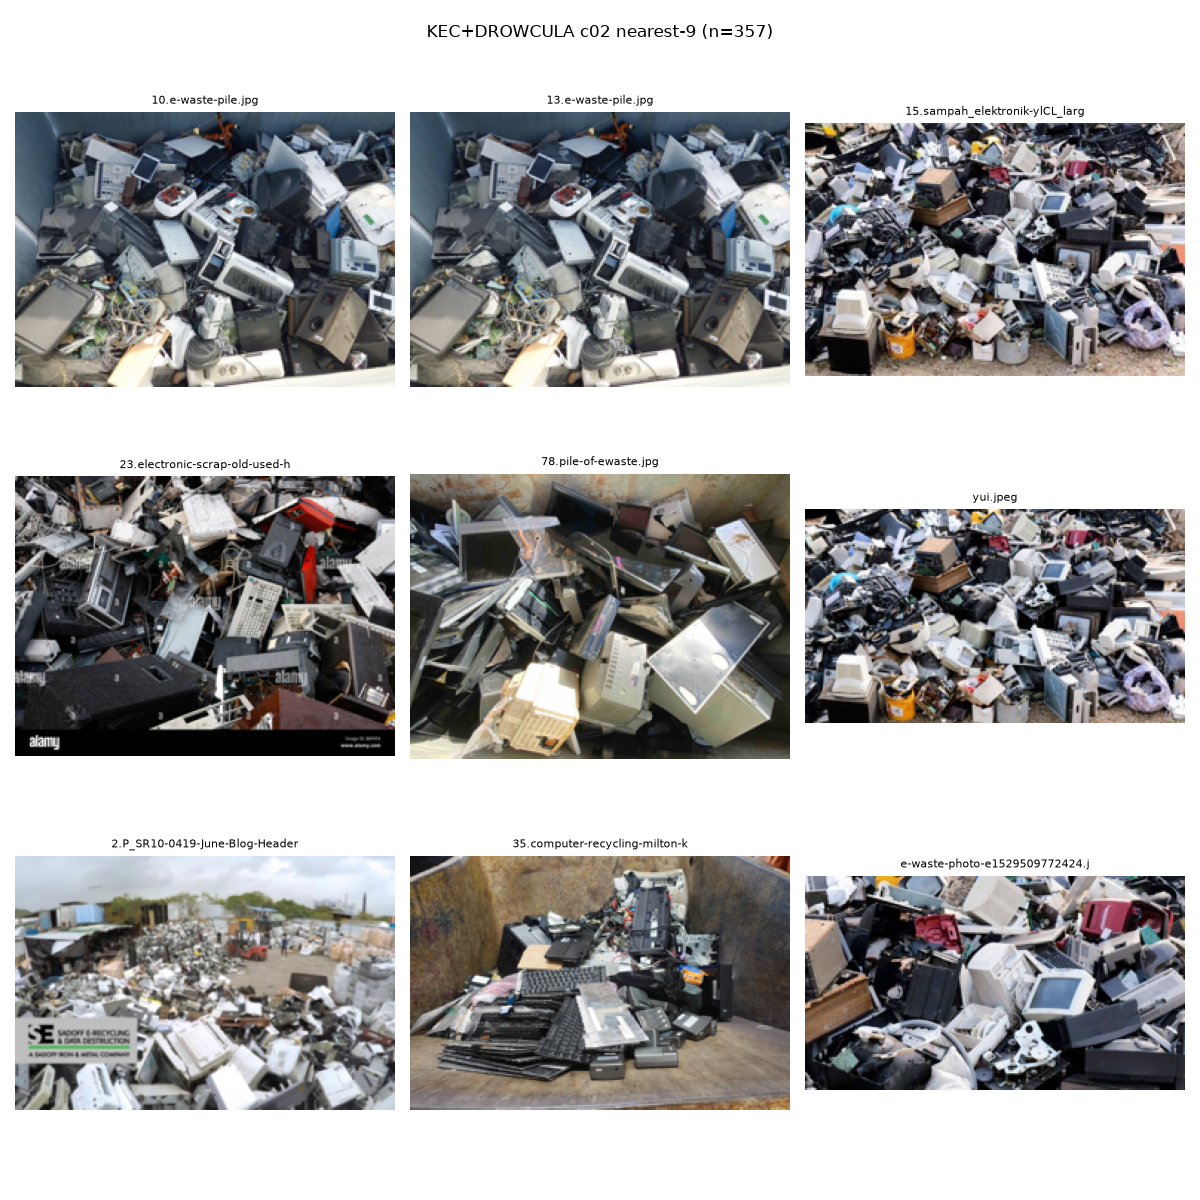

In [8]:
nbdisplay(NBImage(str(FIG / "cluster_c02_top9.png"), width=950))

Menampilkan grid 9 citra terjauh C02 untuk menguji apakah tepi klaster ikut campuran.

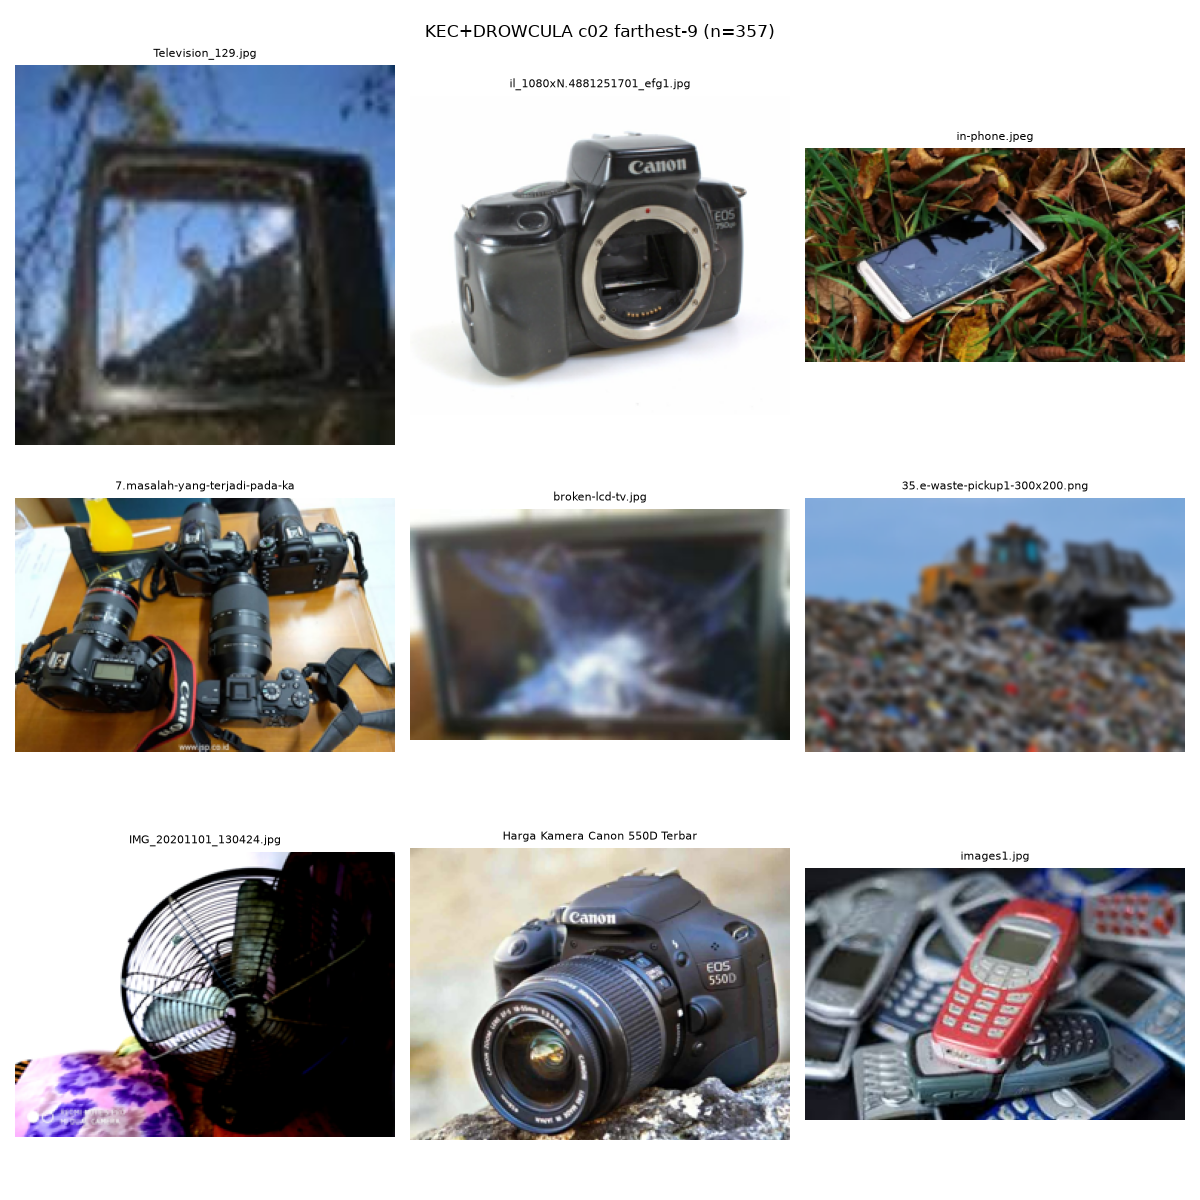

In [9]:
nbdisplay(NBImage(str(FIG / "cluster_c02_far9.png"), width=950))

### ***Kasus Vote Percaya Diri tetapi Salah***
Tiga vote mayoritas justru salah sasaran: C07 vote toaster 0202 sebesar 87% padahal microwave, C14 vote AC 0111 sebesar 67% padahal radio, C04/C13 vote dishwasher 0102 di atas 86% padahal mesin cuci. Grid laptop dan CRT di bawah menunjukkan koreksi manusia yang didukung caption.

Menampilkan grid top-9 C08: vote heterogen 33% yang dikoreksi menjadi laptop oleh manusia dan caption.

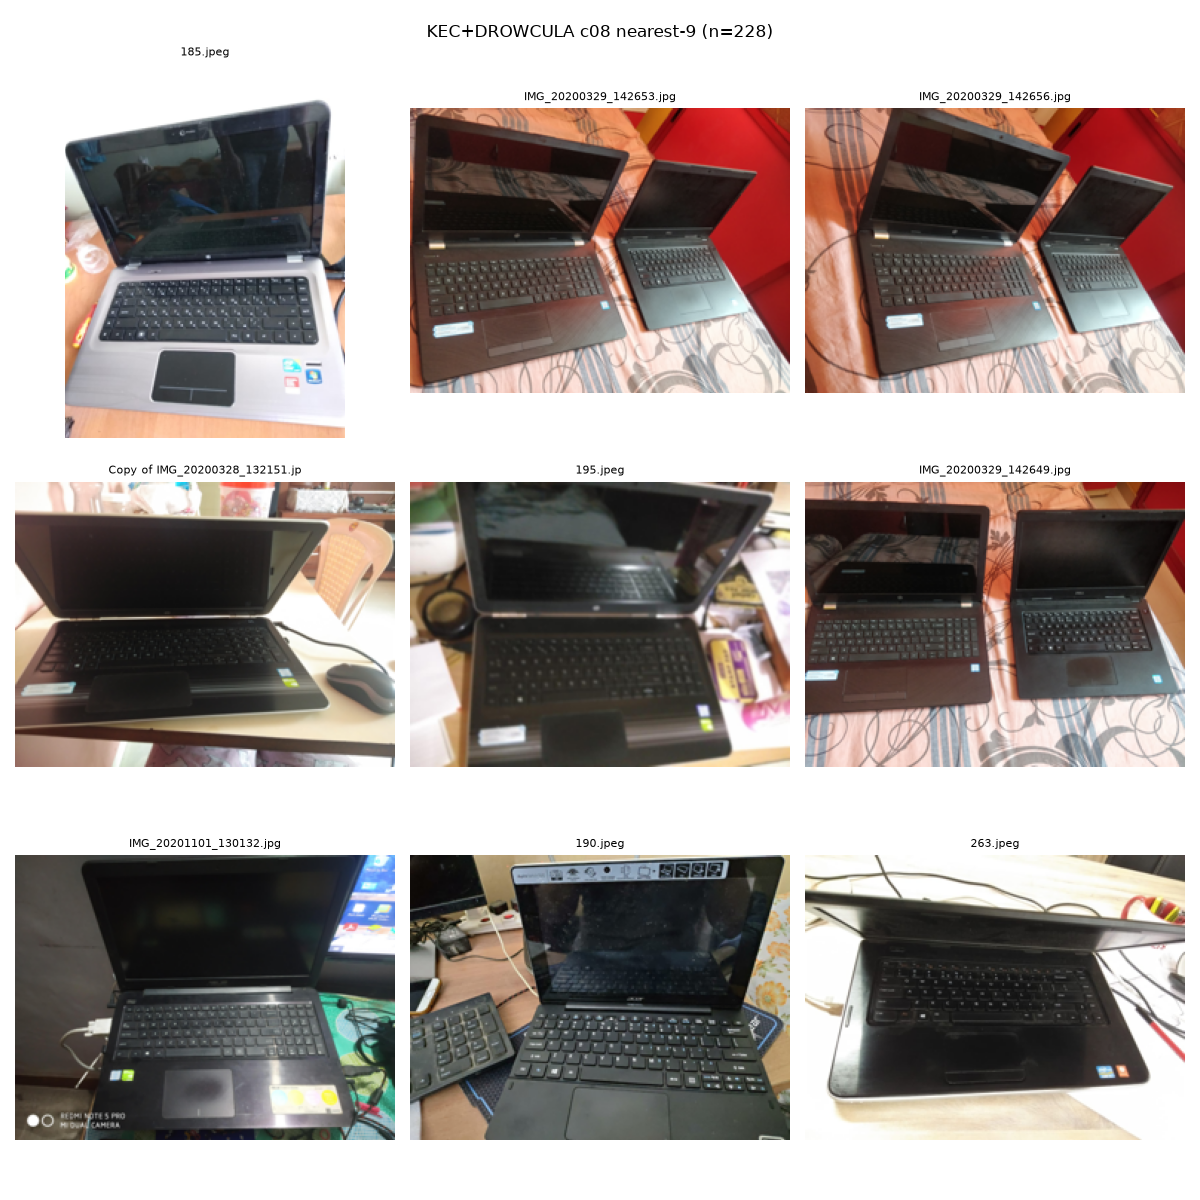

In [10]:
nbdisplay(NBImage(str(FIG / "cluster_c08_top9.png"), width=950))

Menampilkan grid top-9 C11: vote AC 50% yang dikoreksi menjadi CRT convex oleh manusia.

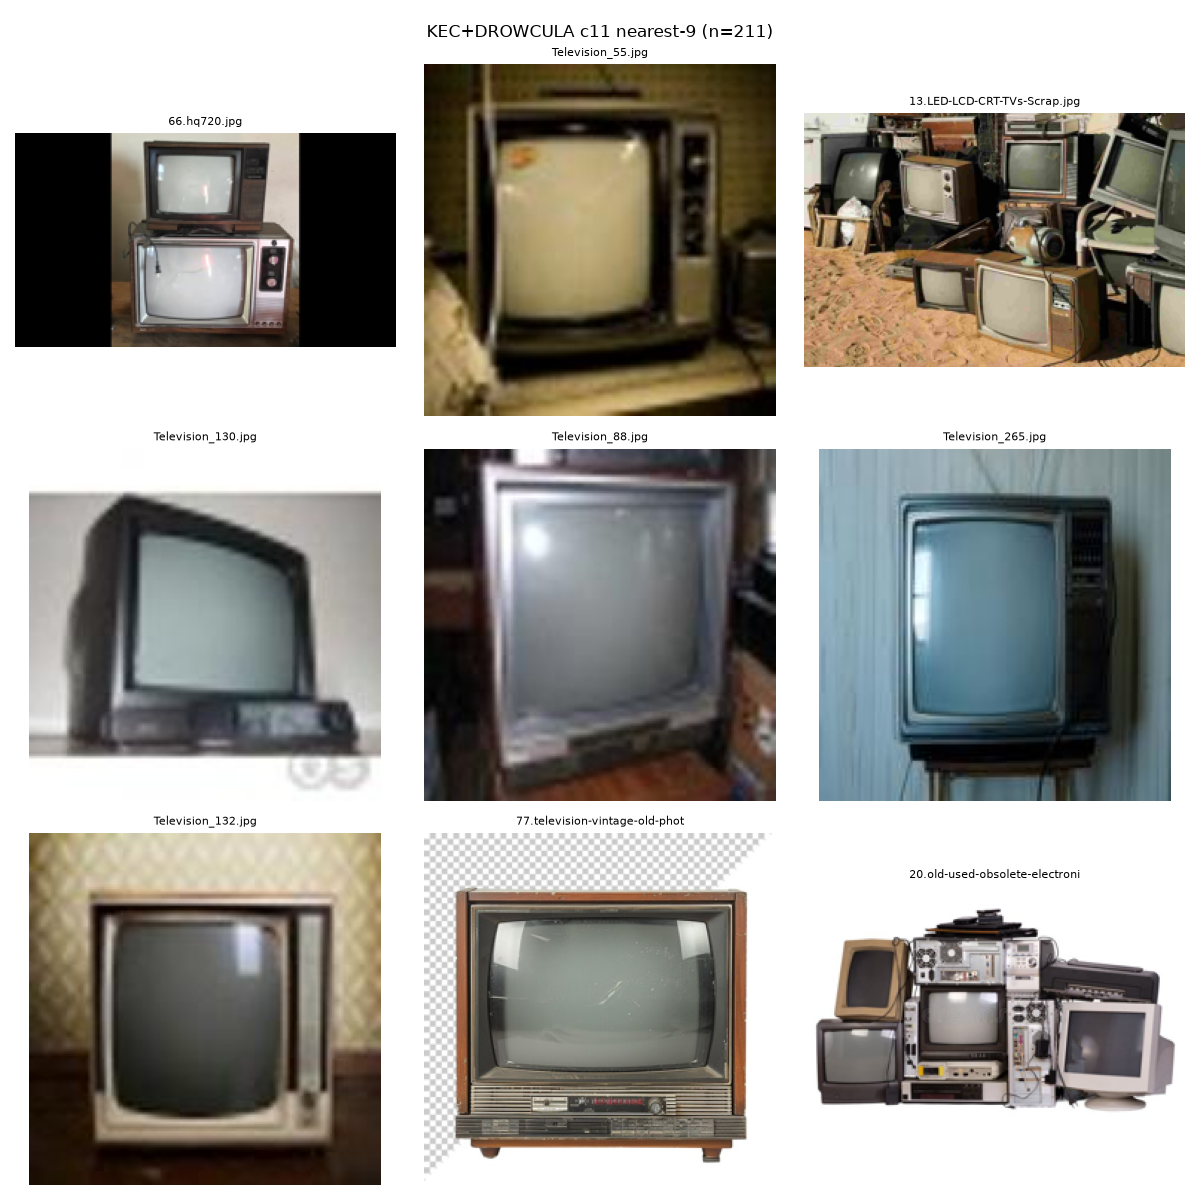

In [11]:
nbdisplay(NBImage(str(FIG / "cluster_c11_top9.png"), width=950))

Menampilkan grid top-9 C14: vote AC 67% yang dikoreksi menjadi radio dan Hi-Fi oleh manusia.

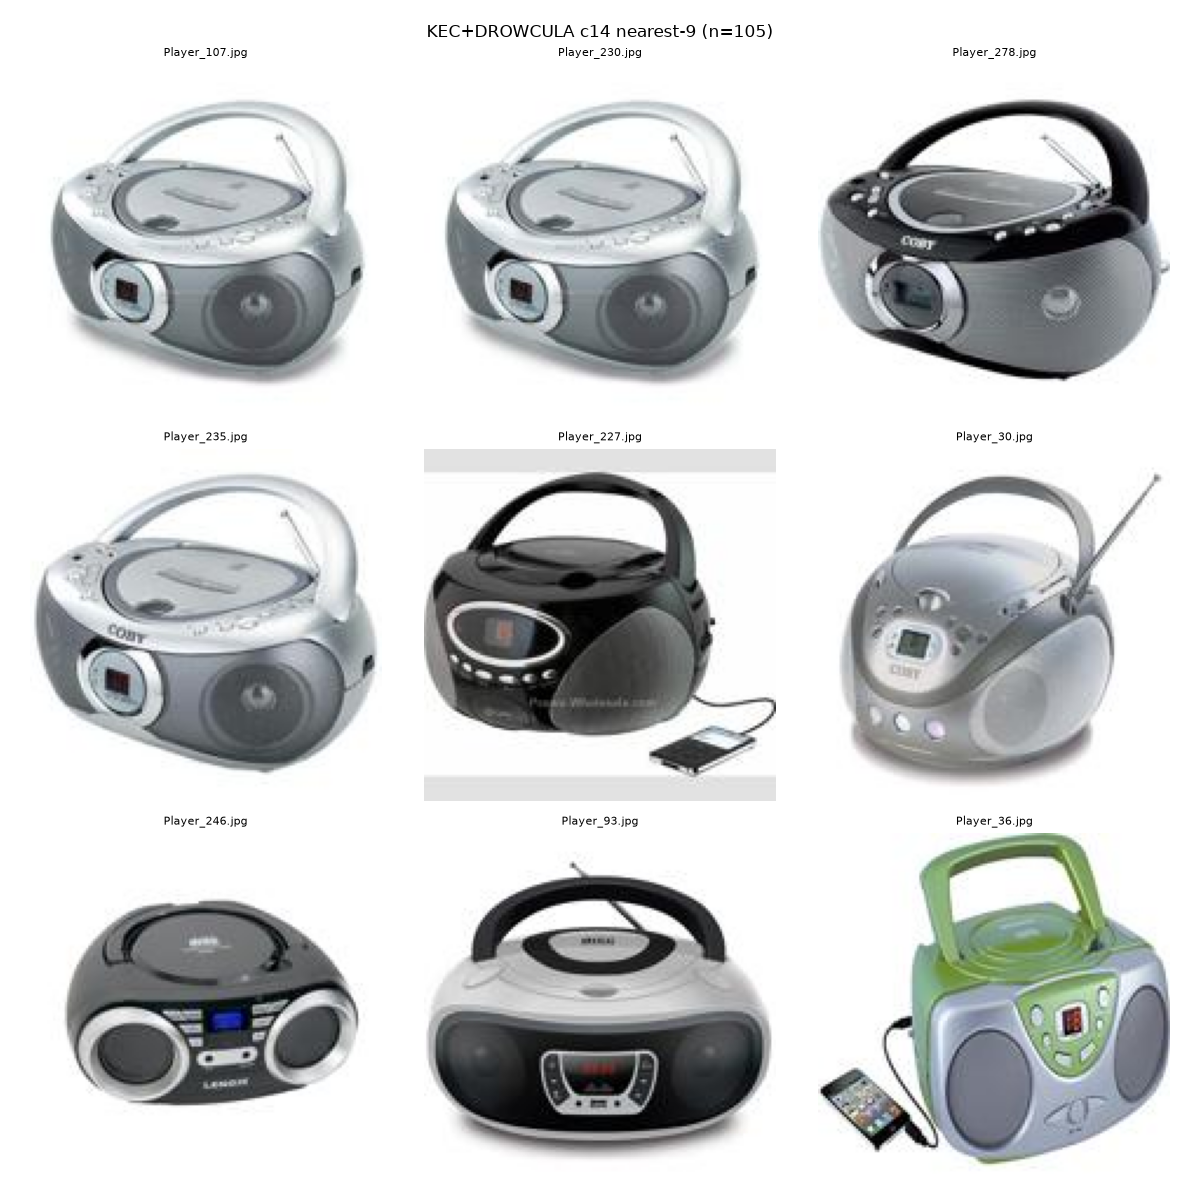

In [12]:
nbdisplay(NBImage(str(FIG / "cluster_c14_top9.png"), width=950))

Menampilkan grid top-9 C16: klaster langka 37 citra tanpa UNU-KEY yang diputuskan sebagai outlet.

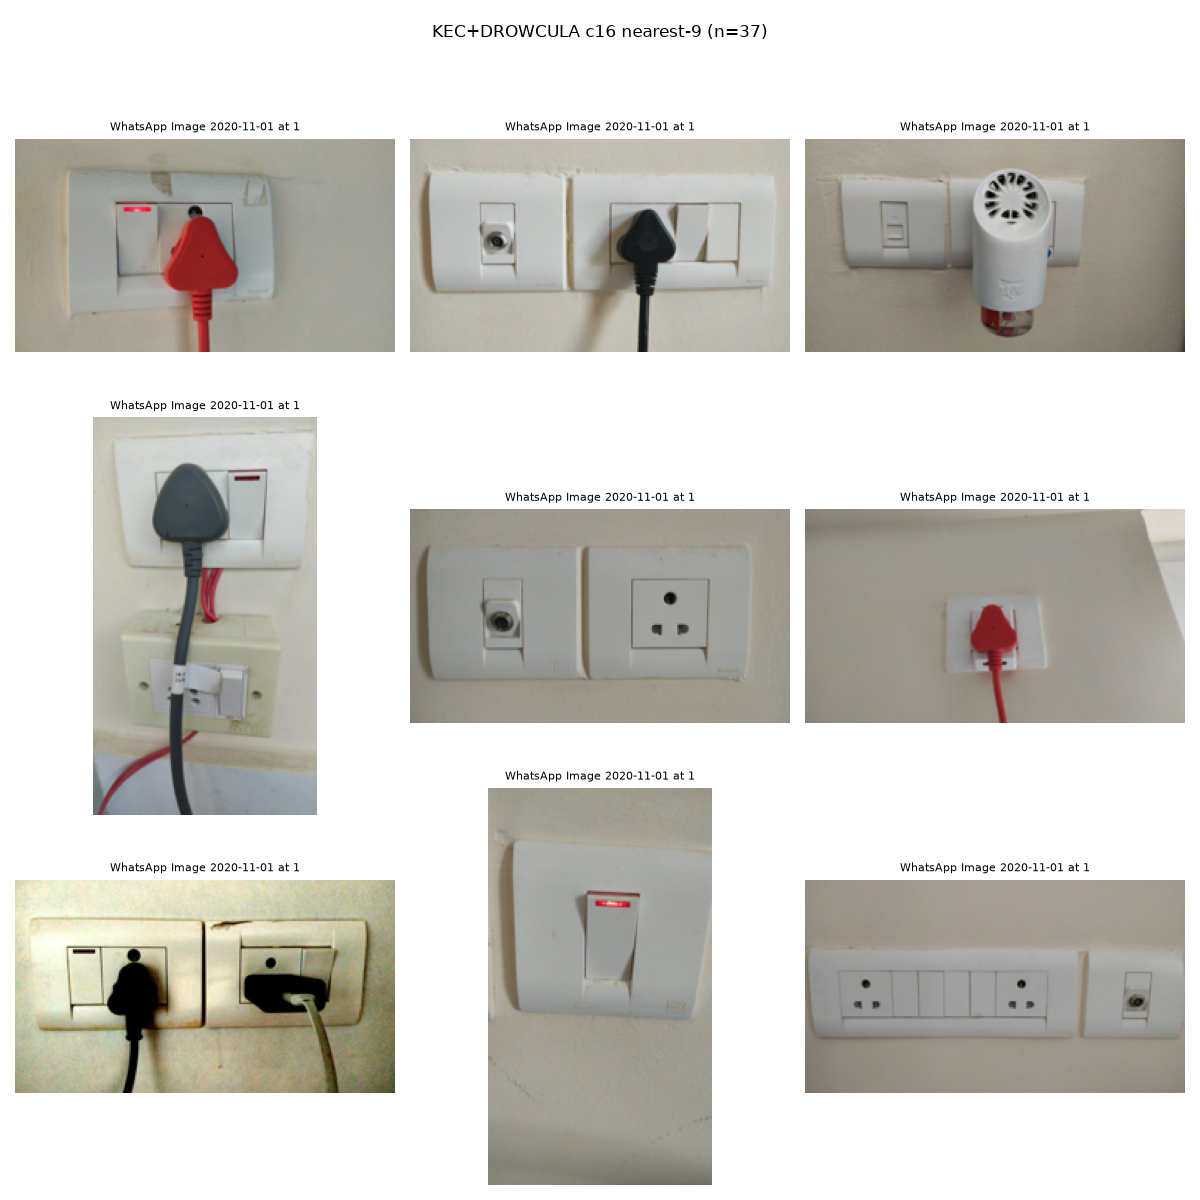

In [13]:
nbdisplay(NBImage(str(FIG / "cluster_c16_top9.png"), width=950))

## ***Audit Caption***
---
Audit kata-kunci konteks atas caption per citra yang sudah ada, tanpa membangkitkan caption baru. Aturan v1: label primer adalah keluarga perangkat yang disebut pertama, perbaikan compound untuk baterai laptop, dan refinement subtype washer dan tv. Ambang SUPPORT 70% dan PARTIAL 40%.

Menampilkan keluarga dominan, persetujuan, dan verdict tiap klaster dalam satu tabel.

In [14]:
a = pd.read_csv(AUD / "cluster_caption_agreement.csv")
show = a[["cluster", "n", "final_label", "dominant_caption_family", "dominant_share",
          "family_agreement", "exact_agreement", "verdict"]].copy()
for c in ["dominant_share", "family_agreement", "exact_agreement"]:
    show[c] = (show[c] * 100).round(1)
show


,cluster,n,final_label,dominant_caption_family,dominant_share,family_agreement,exact_agreement,verdict
0,0,281,Printers and scanners,printer,87.2,87.2,87.2,SUPPORT
1,1,524,Mobile Phones and smartphones,phone,95.0,95.0,95.0,SUPPORT
2,2,357,Mixed e-waste scrap pile,scrap,39.2,39.2,39.2,CONFLICT/HETEROGENEOUS
3,3,290,Keyboards and input devices,keyboard,87.6,87.6,87.6,SUPPORT
4,4,101,Washing Machines (top-load),washer,64.4,64.4,18.8,PARTIAL
5,5,343,Computer mice and pointing devices,mouse,90.7,90.7,90.7,SUPPORT
6,6,141,Televisions (flat-panel),tv,76.6,76.6,53.9,SUPPORT
7,7,242,Microwaves,microwave,95.9,95.9,95.9,SUPPORT
8,8,228,Laptops and tablets,laptop,91.7,91.7,91.7,SUPPORT
9,9,277,Portable batteries,battery,58.5,58.5,58.5,PARTIAL


Menggambar persetujuan caption per klaster dengan garis SUPPORT dan PARTIAL sebagai pembanding vote.

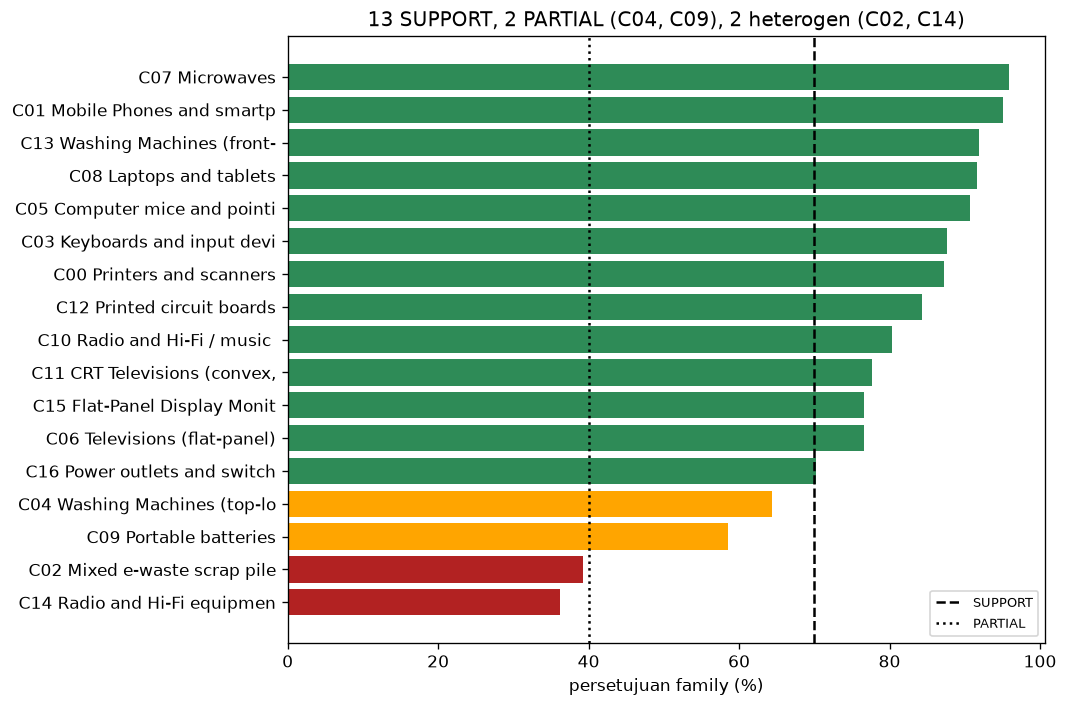

In [15]:
a = pd.read_csv(AUD / "cluster_caption_agreement.csv").sort_values("family_agreement")
vcol = {"SUPPORT": "seagreen", "PARTIAL": "orange", "CONFLICT/HETEROGENEOUS": "firebrick"}
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh([f'C{r.cluster:02d} {str(r.final_label)[:24]}' for r in a.itertuples()],
        a["family_agreement"] * 100, color=[vcol[str(r.verdict)] for r in a.itertuples()])
ax.axvline(70, ls="--", c="k", label="SUPPORT"); ax.axvline(40, ls=":", c="k", label="PARTIAL")
ax.set_xlabel("persetujuan family (%)"); ax.legend(fontsize=8)
ax.set_title("13 SUPPORT, 2 PARTIAL (C04, C09), 2 heterogen (C02, C14)")
fig.tight_layout()
plt.show(fig)


Menyandingkan vote SigLIP2, caption dominan, dan label final untuk triangulasi keputusan tiap klaster.

In [16]:
a = pd.read_csv(AUD / "cluster_caption_agreement.csv")
g = pd.read_csv(KEC / "cluster_grounding.csv")
a2 = a[["cluster", "dominant_caption_family", "dominant_share", "verdict"]]
g2 = g[["cluster", "vote_code", "vote_winner_share"]].rename(columns={"vote_code": "siglip_vote"})
f2 = final[["cluster", "final_label", "unu_key_code", "vote_agreement"]].rename(columns={"final_label": "final_name", "unu_key_code": "final_code", "vote_agreement": "final_vote"})
t = a2.merge(g2, on="cluster").merge(f2, on="cluster")
rows = []
for r in t.sort_values("cluster").itertuples():
    rows.append({"klaster": f"C{r.cluster:02d}",
                 "vote": f"{r.siglip_vote} {r.vote_winner_share:.0%}",
                 "caption": f"{r.dominant_caption_family} {r.dominant_share:.0%} [{r.verdict}]",
                 "final": f'{r.final_code} {r.final_name[:30]} ({r.final_vote})'})
pd.DataFrame(rows)


,klaster,vote,caption,final
0,C00,0304 84%,printer 87% [SUPPORT],0304 Printers and scanners (agree)
1,C01,0306 65%,phone 95% [SUPPORT],0306 Mobile Phones and smartphones (agree)
2,C02,GAP-SCRAP 28%,scrap 39% [CONFLICT/HETEROGENEOUS],GAP-SCRAP Mixed e-waste scrap pile (agree)
3,C03,0301 92%,keyboard 88% [SUPPORT],0301 Keyboards and input devices (agree)
4,C04,0102 86%,washer 64% [PARTIAL],0104 Washing Machines (top-load) (human correc...
5,C05,0301 94%,mouse 91% [SUPPORT],0301 Computer mice and pointing dev (agree)
6,C06,0405/0111/0404? 45%,tv 77% [SUPPORT],0408 Televisions (flat-panel) (human correction)
7,C07,0202 87%,microwave 96% [SUPPORT],0114 Microwaves (human correction)
8,C08,0301/0405/0407? 33%,laptop 92% [SUPPORT],0303 Laptops and tablets (human correction)
9,C09,GAP-BATT 73%,battery 58% [PARTIAL],GAP-BATT Portable batteries (agree)


## ***Risiko dan Nilai***
---
Memuat skor EVI dan HI tiap klaster dari pemetaan berbasis pedoman UNITAR.

Menampilkan skor ekonomi, bahaya baseline, dan kuadran tiap klaster dalam satu tabel.

In [17]:
r = pd.read_csv(KEC / "cluster_risk_value.csv")
show = r[["cluster", "n_samples", "unu_key_code", "short_name", "evi_score",
          "hi_baseline_score", "quadrant_baseline"]].copy()
for c in ["evi_score", "hi_baseline_score"]:
    show[c] = show[c].round(2)
show.sort_values("cluster")


,cluster,n_samples,unu_key_code,short_name,evi_score,hi_baseline_score,quadrant_baseline
0,0,281,0304,Printers & Copiers,32.58,58.16,Q1: Critical Urban Mining
1,1,524,0306,Smartphones,97.61,83.19,Q1: Critical Urban Mining
2,2,357,GAP-SCRAP,Mixed E-waste Scrap,15.25,34.78,Q4: General / Inert Residue
3,3,290,0301,Keyboards,6.37,62.80,Q2: Hazardous Neutralization
4,4,101,0104,Washing Machines,8.43,10.79,Q4: General / Inert Residue
5,5,343,0301,Computer Mice,0.00,58.58,Q2: Hazardous Neutralization
6,6,141,0408,Flat-Panel TVs,37.06,75.19,Q1: Critical Urban Mining
7,7,242,0114,Microwave Ovens,17.22,18.27,Q4: General / Inert Residue
8,8,228,0303,Laptops & Tablets,81.66,82.78,Q1: Critical Urban Mining
9,9,277,GAP-BATT,Batteries & Cells,52.47,34.92,Q3: Fast Circular Recovery


Memetakan tiap klaster di ruang EVI dan HI dengan ukuran titik mengikuti jumlah citra.

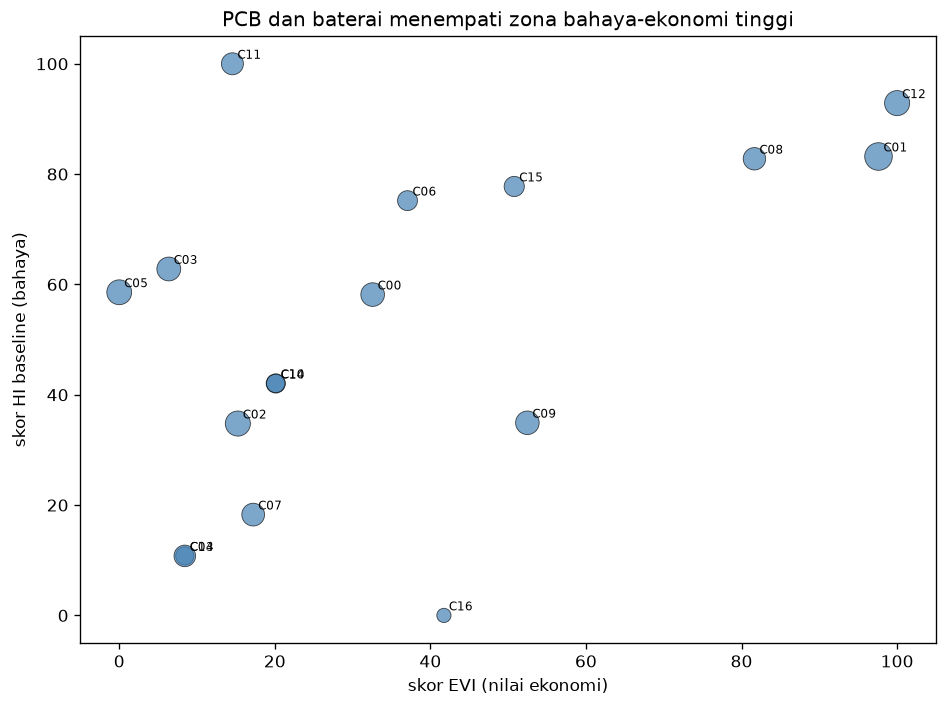

In [18]:
r = pd.read_csv(KEC / "cluster_risk_value.csv")
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(r["evi_score"], r["hi_baseline_score"], s=np.sqrt(r["n_samples"]) * 12,
           c="steelblue", alpha=0.7, edgecolors="k", linewidths=0.5)
for row in r.itertuples():
    ax.annotate(f"C{row.cluster:02d}", (row.evi_score, row.hi_baseline_score), fontsize=7,
                xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("skor EVI (nilai ekonomi)"); ax.set_ylabel("skor HI baseline (bahaya)")
ax.set_title("PCB dan baterai menempati zona bahaya-ekonomi tinggi")
fig.tight_layout()
plt.show(fig)


Mengelompokkan kuadran tiap klaster beserta anggotanya untuk prioritas penanganan.

In [19]:
r = pd.read_csv(KEC / "cluster_risk_value.csv")
grp = r.groupby("quadrant_baseline")
rows = []
for name, d in grp:
    rows.append({"kuadran": name, "n_klaster": len(d),
                 "anggota": ", ".join(f'C{c:02d} {s[:18]}' for c, s in zip(d["cluster"], d["short_name"]))})
pd.DataFrame(rows).sort_values("kuadran")


,kuadran,n_klaster,anggota
0,Q1: Critical Urban Mining,6,"C00 Printers & Copiers, C01 Smartphones, C06 F..."
1,Q2: Hazardous Neutralization,3,"C03 Keyboards, C05 Computer Mice, C11 CRT Tele..."
2,Q3: Fast Circular Recovery,4,"C09 Batteries & Cells, C10 Audio / Hi-Fi, C14 ..."
3,Q4: General / Inert Residue,4,"C02 Mixed E-waste Scra, C04 Washing Machines, ..."


Menandai klaster berisiko merkuri dari daftar Hg pedoman plus aliran baterai dan PCB A1181.

In [20]:
hg = {"0302", "0303", "0306", "0309", "0408", "0502", "0503", "0504"}
t = final.merge(sizes, on="cluster")
rows = []
for r in t.itertuples():
    flag = "Hg-list" if r.unu_key_code in hg else ("A1181" if str(r.eu_category).startswith("Basel A1181") else "-")
    if flag != "-":
        rows.append({"klaster": f"C{r.cluster:02d}", "label": r.final_label[:32], "kode": r.unu_key_code, "flag": flag, "n": r.size})
pd.DataFrame(rows).sort_values("klaster")


,klaster,label,kode,flag,n
0,C01,Mobile Phones and smartphones,0306,Hg-list,524
1,C06,Televisions (flat-panel),0408,Hg-list,141
2,C08,Laptops and tablets,0303,Hg-list,228
3,C09,Portable batteries,GAP-BATT,A1181,277
4,C12,Printed circuit boards,GAP-PCB,A1181,356
5,C15,Flat-Panel Display Monitors,0309,Hg-list,150


Menghitung komposisi citra per grup EU dan GAP dari ukuran klaster final terkunci.

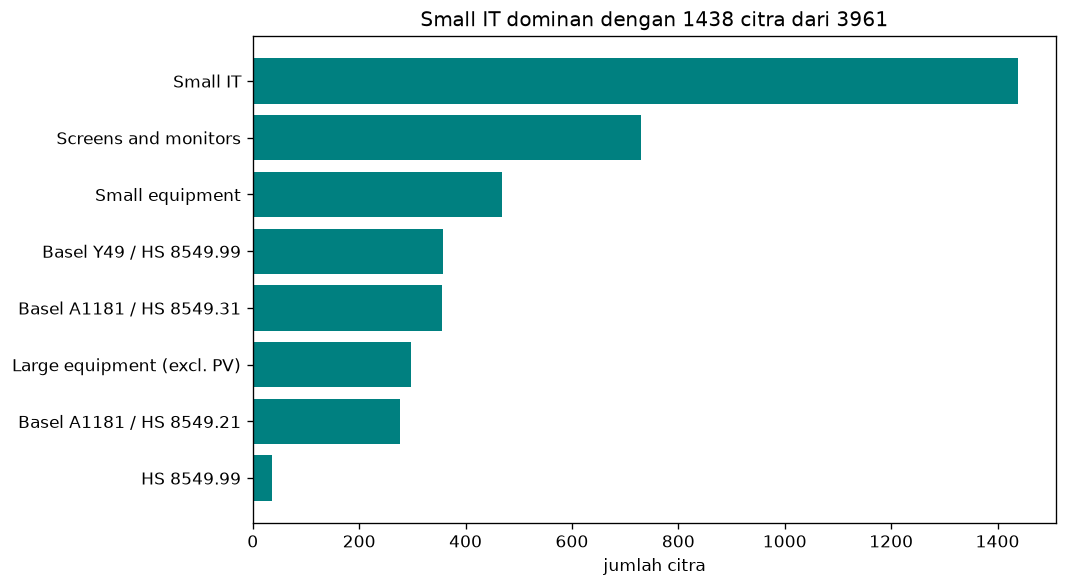

In [21]:
t = sizes.merge(final[["cluster", "eu_category"]], on="cluster")
comp = t.groupby("eu_category")["size"].sum().sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(comp.index, comp.values, color="teal")
ax.set_xlabel("jumlah citra")
ax.set_title("Small IT dominan dengan 1438 citra dari 3961")
fig.tight_layout()
plt.show(fig)


## ***Kesimpulan***
---
Rantai pelabelan terbukti berlapis: centroid lemah 0/17 HIGH, vote per citra menyelamatkan 11 klaster tetapi 3 vote mayoritas salah sasaran, grid top-9 memutuskan 10 koreksi, dan caption triangulasi dengan 13 SUPPORT serta hanya C02 dan C14 heterogen murni. Peta EVI-HI menutup alur dengan prioritas nyata: C12 PCB dan C09 baterai di zona bahaya tinggi, C11 CRT di zona netralisasi, dan Small IT sebagai massa daur ulang terbesar.